In [37]:
import pandas as pd

In [38]:
data = pd.read_csv('merged_similarity_analysis.csv')
data.head(20)

,file_name,similar_file,distance_raw,distance_mod,top_K
0,title_000fafe617351d803c43c1cf03a3830c,title_000fafe617351d803c43c1cf03a3830c,0.974940,1.003125,10000
1,title_000fafe617351d803c43c1cf03a3830c,title_af6c65a0b2653ab871b3c15055ebac5c,0.827596,0.851898,10000
2,title_000fafe617351d803c43c1cf03a3830c,title_a0ec52fb81e5833287c497ed67a1b541,0.668647,0.698017,10000
3,title_000fafe617351d803c43c1cf03a3830c,title_ccf4300e2f18dd6b1e2c877c174604dc,0.596569,0.626431,10000
4,title_000fafe617351d803c43c1cf03a3830c,title_d61d3ab81fe17bbe35ece63cc9d8e401,0.597945,0.626146,10000
5,title_000fafe617351d803c43c1cf03a3830c,title_1b9aa1844ae11deb1f6d7ecffd09f09e,0.592234,0.623293,10000
6,title_000fafe617351d803c43c1cf03a3830c,title_cf20925aa15e24df058ac00c2b2a760e,0.590885,0.619477,10000
7,title_000fafe617351d803c43c1cf03a3830c,title_3b66e2564f1e0d1552fcaa7ef0924165,0.585240,0.615964,10000
8,title_000fafe617351d803c43c1cf03a3830c,title_c46ceeeb2d011a565bbc59210e111199,0.574158,0.605564,10000
9,title_000fafe617351d803c43c1cf03a3830c,title_829ec32d9b11d5f70b57d616983d49eb,0.570532,0.602405,10000


In [39]:
data.describe()

,distance_raw,distance_mod,top_K
count,8.600500e+06,8.600500e+06,8.600500e+06
mean,4.420493e-01,4.632989e-01,2.537642e+03
std,1.782511e-01,1.823031e-01,3.148722e+03
min,0.000000e+00,2.273467e-04,5.000000e+01
25%,3.203524e-01,3.388085e-01,3.500000e+02
50%,4.480529e-01,4.702019e-01,1.000000e+03
75%,5.609861e-01,5.856436e-01,5.000000e+03
max,5.595468e+01,5.597692e+01,1.000000e+04


In [40]:
import pandas as pd

TOP_K = sorted(data['top_K'].unique())

# Hard-coded stat rows
stats = [
    {"stat": "count"},
    {"stat": "mean"},
    {"stat": "std"},
    {"stat": "min"},
    {"stat": "25%"},
    {"stat": "50%"},
    {"stat": "75%"},
    {"stat": "max"},
    {"stat": ">1"}
]

# Convert to dict for easier assignment
stats_map = {row["stat"]: row for row in stats}

# Fill values
for top_k in TOP_K:
    subset = data[data['top_K'] == top_k]
    
    raw_desc = subset['distance_raw'].describe()
    mod_desc = subset['distance_mod'].describe()
    
    raw_desc['>1'] = (subset['distance_raw'] > 1).sum()
    mod_desc['>1'] = (subset['distance_mod'] > 1).sum()
    
    for stat in stats_map:
        stats_map[stat][f'distance_raw_{top_k}'] = raw_desc[stat]
        stats_map[stat][f'distance_mod_{top_k}'] = mod_desc[stat]

# Convert back to DataFrame
final_df = pd.DataFrame(stats)

# Hard-coded column order
cols = ['stat']
for k in TOP_K:
    cols.append(f'distance_raw_{k}')
    cols.append(f'distance_mod_{k}')

final_df = final_df[cols]
final_df.transpose().head(30)

,0,1,2,3,4,5,6,7,8
stat,count,mean,std,min,25%,50%,75%,max,>1
distance_raw_50,716550.0,0.226111,0.105913,0.0,0.143288,0.20623,0.296077,0.905096,0.0
distance_mod_50,716550.0,0.238603,0.107456,0.003175,0.154454,0.218782,0.31009,0.915964,0.0
distance_raw_100,716550.0,0.280701,0.111686,0.0,0.196998,0.264333,0.354103,0.917616,0.0
distance_mod_100,716550.0,0.296183,0.113651,0.003279,0.2111,0.279984,0.371219,0.92996,0.0
distance_raw_200,716650.0,0.344905,0.128881,0.0,0.259975,0.334843,0.424198,37.661129,150.0
distance_mod_200,716650.0,0.363099,0.130846,0.000604,0.276911,0.353284,0.444225,37.676044,156.0
distance_raw_350,716750.0,0.400029,0.140364,0.0,0.307556,0.392971,0.489184,37.664761,150.0
distance_mod_350,716750.0,0.420662,0.142753,0.000227,0.326716,0.413846,0.511682,37.67997,158.0
distance_raw_500,716750.0,0.432679,0.141808,0.0,0.341842,0.430146,0.522403,37.760841,155.0


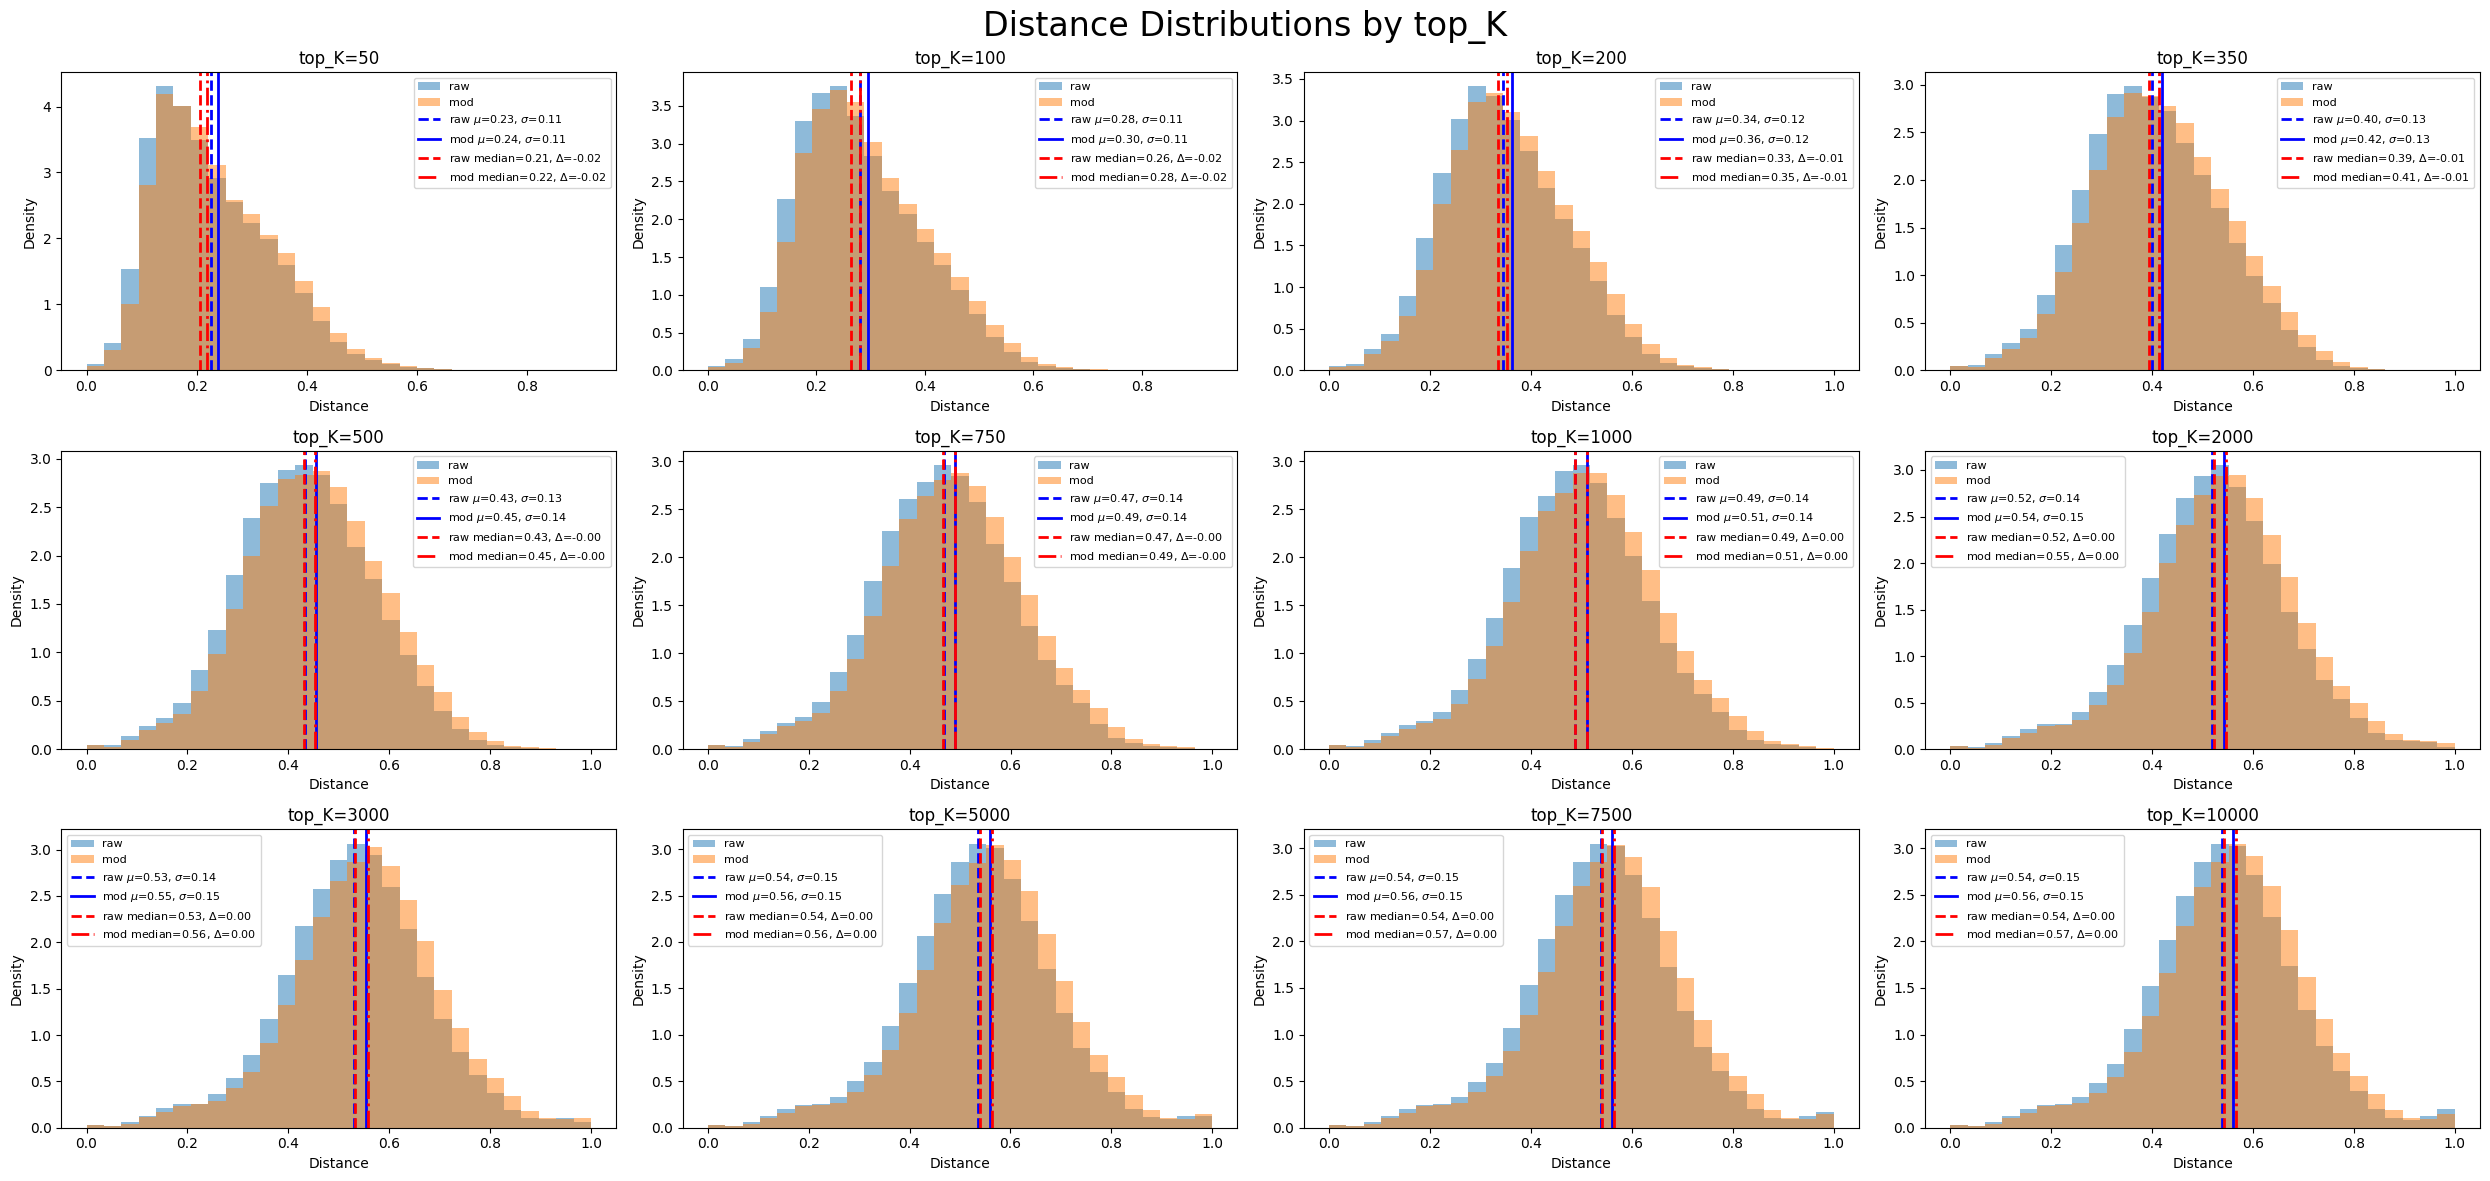

In [41]:
import matplotlib.pyplot as plt
import numpy as np

TOP_K = sorted(data['top_K'].unique())

n_cols = 4
n_rows = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 12))
axes = axes.flatten()

for i, top_k in enumerate(TOP_K):
    ax = axes[i]
    subset = data[data['top_K'] == top_k]

    raw = subset['distance_raw']
    mod = subset['distance_mod']

    # Optional: filter range for stability
    raw = raw[(raw >= 0) & (raw <= 1)]
    mod = mod[(mod >= 0) & (mod <= 1)]

    # Shared bins for fair comparison
    bins = np.linspace(
        min(raw.min(), mod.min()),
        max(raw.max(), mod.max()),
        30
    )

    # Plot histograms (density for better overlay)
    ax.hist(raw, bins=bins, alpha=0.5, label='raw', density=True)
    ax.hist(mod, bins=bins, alpha=0.5, label='mod', density=True)

    # Means
    raw_mean = raw.mean()
    mod_mean = mod.mean()

    # Vertical lines (mean + std)
    ax.axvline( raw_mean, linestyle='--', linewidth=2, color='blue', label=fr'raw $\mu$={raw_mean:.2f}, $\sigma$={raw.std():.2f}')

    ax.axvline(mod_mean,linestyle='-',linewidth=2,color='blue',label=fr'mod $\mu$={mod_mean:.2f}, $\sigma$={mod.std():.2f}')

    # Medians
    raw_median = raw.median()
    ax.axvline(raw_median,linestyle='--',linewidth=2,color='red',label=fr'raw median={raw_median:.2f}, $\Delta$={raw_median - raw_mean:.2f}')

    mod_median = mod.median()
    ax.axvline(mod_median,linestyle='-.',linewidth=2,color='red',label=fr'mod median={mod_median:.2f}, $\Delta$={mod_median - mod_mean:.2f}')

    ax.set_title(f'top_K={top_k}')
    ax.set_xlabel('Distance')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

# Hide unused subplots if TOP_K < 12
for j in range(len(TOP_K), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distance Distributions by top_K', fontsize=24)
plt.tight_layout()
plt.show()

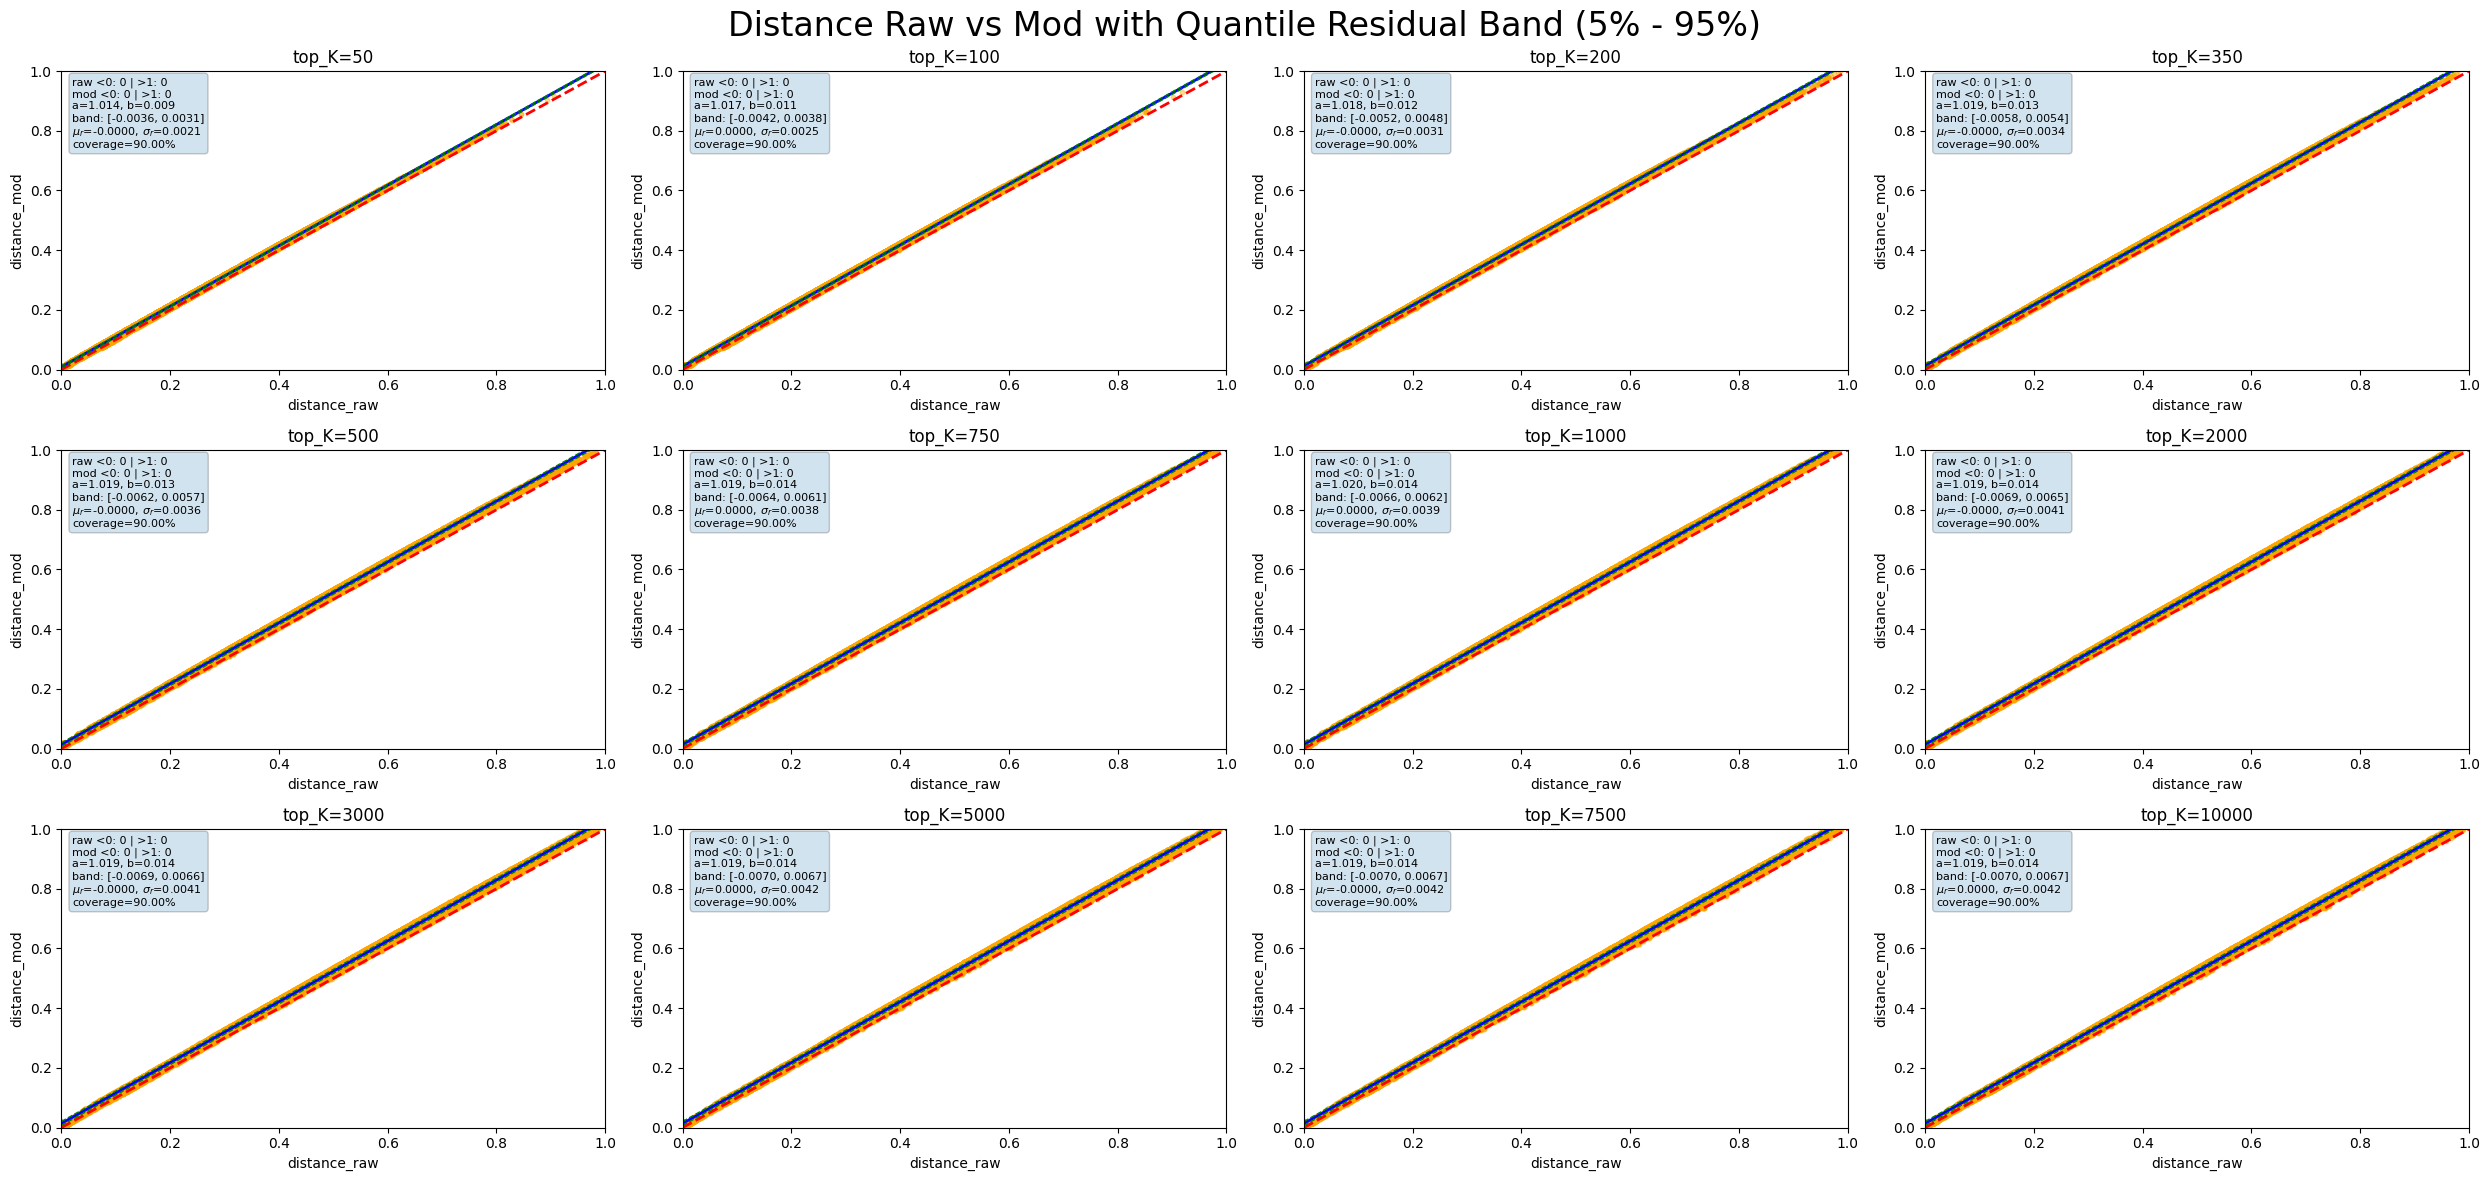

In [53]:
import matplotlib.pyplot as plt
import numpy as np

TOP_K = sorted(data['top_K'].unique())

n_cols = 4
n_rows = 3
q_low, q_high = 0.05, 0.95

fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 12))
axes = axes.flatten()

data_less_1 = data[(data['distance_raw'] <= 1) & (data['distance_mod'] <= 1)].reset_index(drop=True)

for i, top_k in enumerate(TOP_K):
    ax = axes[i]
    subset = data_less_1[data_less_1['top_K'] == top_k]

    raw = subset['distance_raw']
    mod = subset['distance_mod']

    # Count out-of-bounds
    raw_below = (raw < 0).sum()
    raw_above = (raw > 1).sum()
    mod_below = (mod < 0).sum()
    mod_above = (mod > 1).sum()

    # Scatter
    ax.scatter(raw, mod, alpha=0.4, s=10, color='orange')

    # Reference line y = x
    x = np.linspace(0, 1, 200)
    ax.plot(x, x, linestyle='--', linewidth=2, color='red')

    # Fit linear model
    a, b = np.polyfit(raw, mod, 1)

    y_center = a * x + b

    # Residuals
    residuals = mod - (a * raw + b)

    # Quantile band (robust)
    r_low = np.quantile(residuals, q_low)
    r_high = np.quantile(residuals, q_high)

    # Band lines
    y1 = np.clip(y_center + r_low, 0, 1)
    y2 = np.clip(y_center + r_high, 0, 1)

    ax.plot(x, y_center, linewidth=2, label='fit', color='blue')
    ax.plot(x, y1, linestyle='--', linewidth=1, color='green', label=f'{int(q_low*100)}% quantile')
    ax.plot(x, y2, linestyle='--', linewidth=1, color='green', label=f'{int(q_high*100)}% quantile')
    ax.fill_between(x, y1, y2, alpha=0.1)

    # Coverage
    y_pred = a * raw + b
    inside = ((mod >= y_pred + r_low) &
              (mod <= y_pred + r_high)).mean()

    # Residual stats
    r_std = residuals.std()
    r_mean = residuals.mean()

    # Labels
    ax.set_title(f'top_K={top_k}')
    ax.set_xlabel('distance_raw')
    ax.set_ylabel('distance_mod')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Annotation
    text = (
        f'raw <0: {raw_below} | >1: {raw_above}\n'
        f'mod <0: {mod_below} | >1: {mod_above}\n'
        f'a={a:.3f}, b={b:.3f}\n'
        f'band: [{r_low:.4f}, {r_high:.4f}]\n'
        f'$\\mu_r$={r_mean:.4f}, $\\sigma_r$={r_std:.4f}\n'
        f'coverage={inside:.2%}'
    )

    ax.text(
        0.02, 0.98, text,
        transform=ax.transAxes,
        va='top',
        fontsize=8,
        bbox=dict(boxstyle='round', alpha=0.2)
    )

# Hide unused
for j in range(len(TOP_K), len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Distance Raw vs Mod with Quantile Residual Band ({int(q_low*100)}% - {int(q_high*100)}%)', fontsize=24)
plt.tight_layout()
plt.show()

In [63]:
residuals = data_less_1['distance_mod'] - data_less_1['distance_raw']
low_bound, high_bound = 0.05, 0.95
r_low = np.quantile(residuals, low_bound)
r_high = np.quantile(residuals, high_bound)
print(f"Estimated quantile residual band: [{r_low:.4f}, {r_high:.4f}]\n({(high_bound-low_bound)*100:.0f}% of residuals fall within this range)")

def estimate_mod_interval(x):
    return (
        x + r_low,
        x + r_high
    )

# A list of random number to test the interval estimation
test_values = np.random.uniform(0, 1, size=20)
for val in test_values:
    low, high = estimate_mod_interval(val)
    print(f'raw={val:.3f} => mod in [{low:.3f}, {high:.3f}] with {(high_bound-low_bound)*100:.0f}% confidence')

Estimated quantile residual band: [0.0115, 0.0306]
(90% of residuals fall within this range)
raw=0.933 => mod in [0.944, 0.963] with 90% confidence
raw=0.335 => mod in [0.346, 0.365] with 90% confidence
raw=0.721 => mod in [0.733, 0.752] with 90% confidence
raw=0.353 => mod in [0.364, 0.383] with 90% confidence
raw=0.452 => mod in [0.464, 0.483] with 90% confidence
raw=0.744 => mod in [0.756, 0.775] with 90% confidence
raw=0.266 => mod in [0.277, 0.296] with 90% confidence
raw=0.854 => mod in [0.866, 0.885] with 90% confidence
raw=0.551 => mod in [0.563, 0.582] with 90% confidence
raw=0.178 => mod in [0.190, 0.209] with 90% confidence
raw=0.223 => mod in [0.234, 0.253] with 90% confidence
raw=0.360 => mod in [0.371, 0.390] with 90% confidence
raw=0.913 => mod in [0.924, 0.943] with 90% confidence
raw=0.400 => mod in [0.411, 0.430] with 90% confidence
raw=0.219 => mod in [0.231, 0.250] with 90% confidence
raw=0.630 => mod in [0.641, 0.660] with 90% confidence
raw=0.385 => mod in [0.397,

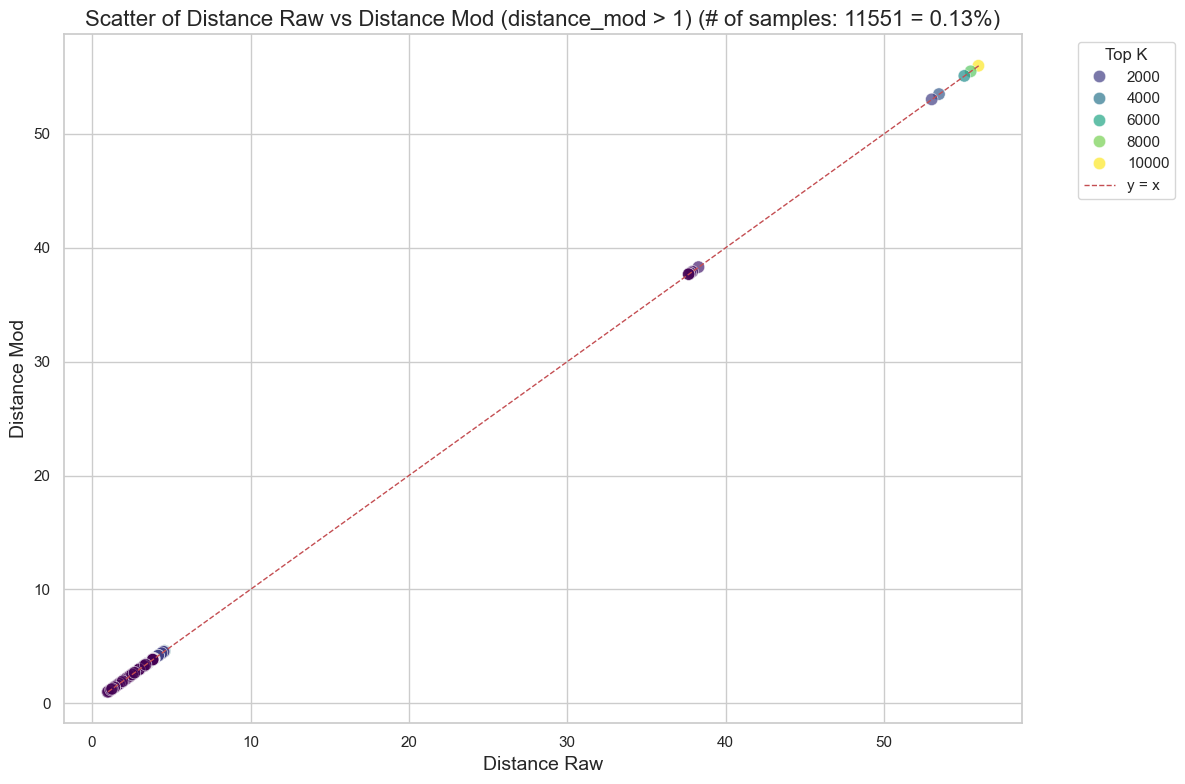

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a clean Seaborn style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Filter the subset
subset = data[data['distance_mod'] > 1].reset_index(drop=True)
subset = subset[['distance_raw', 'distance_mod', 'top_K']]

# Scatter plot with better aesthetics
scatter = sns.scatterplot(
    data=subset,
    x='distance_raw',
    y='distance_mod',
    hue='top_K',
    palette='viridis',
    alpha=0.7,
    s=80,           # marker size
    edgecolor='w',  # white edges for better separation
    linewidth=0.5
)

# Optional: add a diagonal reference line (distance_raw = distance_mod)
max_val = max(subset['distance_raw'].max(), subset['distance_mod'].max())
plt.plot([1, max_val], [1, max_val], 'r--', linewidth=1, label='y = x')

# Titles and labels
plt.title(f'Scatter of Distance Raw vs Distance Mod (distance_mod > 1) (# of samples: {len(subset)} = {len(subset)/len(data)*100:.2f}%)', fontsize=16)
plt.xlabel('Distance Raw', fontsize=14)
plt.ylabel('Distance Mod', fontsize=14)

# Move legend outside
plt.legend(title='Top K', bbox_to_anchor=(1.05, 1), loc='upper left')

# Tight layout for better spacing
plt.tight_layout()
plt.show()

In [46]:
import pandas as pd
import numpy as np

# Load your existing histogram table
bar_dist = pd.read_csv('bin_info.csv')  # columns: bin_index, count, bin_start, bin_end
bar_dist.tail(20)

,bin_index,count,bin_start,bin_end
47,47,6,3.001427,3.023829
48,48,2,3.083398,3.083417
49,49,10,3.142020,3.183702
50,50,1,3.244008,3.244008
51,51,3,3.277228,3.284347
52,52,6,3.338294,3.375622
53,53,4,3.394413,3.428430
54,54,1,3.484474,3.484474
55,55,2,3.520965,3.520978
56,56,4,3.607514,3.616089


In [47]:
target_count = bar_dist['count'].sum() * 0.86 # Top 86% of the data
print(f"Total count: {bar_dist['count'].sum()}, Target count for top 86%: {int(target_count)}")
temp = bar_dist.sort_values(by='bin_end', ascending=False).reset_index(drop=True)
temp['cumulative_count'] = temp['count'].cumsum()
threshold_index = temp[temp['cumulative_count'] >= target_count].index[0]
threshold_distance = temp.loc[threshold_index, 'bin_end']
print(f"Distance threshold for top 86%: {threshold_distance}")
temp.tail(20)

Total count: 180916790, Target count for top 86%: 155588439
Distance threshold for top 86%: 0.12757627197474


,bin_index,count,bin_start,bin_end,cumulative_count
47,19,483,1.212406e+00,1.275554,3818
48,18,524,1.148332e+00,1.211901,4342
49,17,605,1.084560e+00,1.147769,4947
50,16,745,1.020631e+00,1.084125,5692
51,15,1242,9.568293e-01,1.020532,6934
52,14,2492,8.930352e-01,0.956800,9426
53,13,9705,8.292510e-01,0.892982,19131
54,12,35835,7.654579e-01,0.829239,54966
55,11,99962,7.016698e-01,0.765457,154928
56,10,228734,6.378815e-01,0.701669,383662


In [48]:
results = []; sum_count = 0;  start = bar_dist['bin_start'].min(); end = 0
total = bar_dist['count'].sum()
target_count = 155588439/100
for bin_index in bar_dist['bin_index'].to_list():
    sum_count += bar_dist.loc[bar_dist['bin_index'] == bin_index, 'count'].values[0]
    if sum_count >= target_count:
        end = bar_dist.loc[bar_dist['bin_index'] == bin_index, 'bin_end'].values[0]
        results.append({
            "bin_start": start,
            "bin_end": end,
            "count": sum_count,
            "percentage": sum_count / total * 100
        })
        start = end
        sum_count = 0

if sum_count > 0:
    results.append({
        "bin_start": start,
        "bin_end": bar_dist['bin_end'].max(),
        "count": sum_count,
        "percentage": sum_count / total * 100
    })

results_df = pd.DataFrame(results)
# results_df = results_df.sort_values(by='bin_end', ascending=False).reset_index(drop=True)
results_df['cummulative_percentage'] = results_df['percentage'].cumsum()
# Rounding up to 4 decimal places
results_df['bin_start'] = results_df['bin_start'].round(4)
results_df['bin_end'] = results_df['bin_end'].round(4)

results_df.head(20)

,bin_start,bin_end,count,percentage,cummulative_percentage
0,0.0000,0.0638,15722477,8.690447,8.690447
1,0.0638,0.1276,51579028,28.509807,37.200254
2,0.1276,0.1914,49315569,27.258702,64.458956
3,0.1914,0.2552,31040972,17.157596,81.616552
4,0.2552,0.3189,16821437,9.297886,90.914438
5,0.3189,0.3827,8497280,4.696789,95.611227
6,0.3827,0.4465,4121547,2.278145,97.889372
7,0.4465,0.5103,1981250,1.095117,98.984489
8,0.5103,0.7017,1682302,0.929876,99.914365
9,0.7017,6.3788,154928,0.085635,100.000000


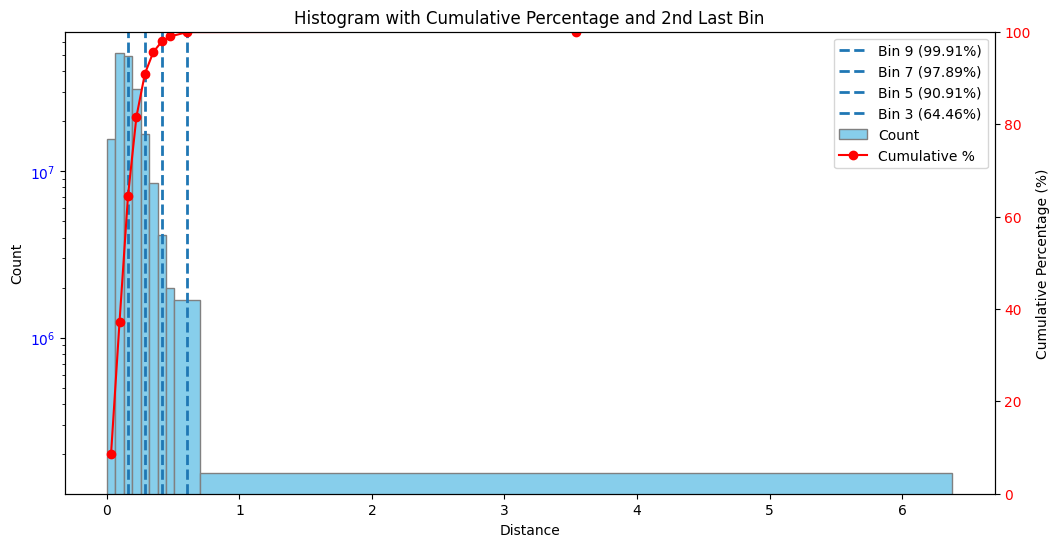

In [49]:
import matplotlib.pyplot as plt

# Bin centers and widths
bin_centers = (results_df['bin_start'] + results_df['bin_end']) / 2
bin_widths = results_df['bin_end'] - results_df['bin_start']

fig, ax1 = plt.subplots(figsize=(12,6))

# Bar plot: counts per bin
ax1.bar(bin_centers, results_df['count'], width=bin_widths, color='skyblue', edgecolor='gray', label='Count')
ax1.set_xlabel('Distance')
ax1.set_ylabel('Count')
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor='blue')

# Line plot: cumulative percentage
ax2 = ax1.twinx()
ax2.plot(bin_centers, results_df['cummulative_percentage'], color='red', marker='o', label='Cumulative %')
ax2.set_ylabel('Cumulative Percentage (%)')
ax2.set_ylim(0, 100)
ax2.tick_params(axis='y', labelcolor='red')

# Add vertical line at 2nd last entry
for i in [len(results_df)-2-i*2 for i in range(0, 4)]:
    bin = results_df.iloc[i]
    vline_pos = (bin['bin_start'] + bin['bin_end']) / 2
    ax1.axvline(x=vline_pos, linestyle='--', linewidth=2, label=f'Bin {i+1} ({bin['cummulative_percentage']:.2f}%)')

# Add legends
fig.legend(loc="upper right", bbox_to_anchor=(0.9,0.88))
plt.title('Histogram with Cumulative Percentage and 2nd Last Bin')
plt.show()